**Using PINNs to find out how long it takes for a beer (or non-alcoholic, for those who prefer so :)) bottle to cool down in a fridge**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

In [36]:
# Modelling the bottle as an infinitely long (not true, but whatever, I want to stick to 2 spatial dimensions) cylinder of radius R
# the bottle is originally at 22 degrees
# It sits in the fridge with no convective heat trasnfer, just constant temperature at the boundary (4 C)
# Goal: understand when the average temperature of the bottle cools down to a target temperature (say 6 C)
# simple heat equation with Dirichlet boundary conditions, no recirculations inside the bottle

bottle_radius = 0.02
target_temperature = 6
alpha_water = 0.133e-6 #m2/s thermal diffusivity of water

#strategy: solve for alpha = 1. then rescale t -> t / alpha_water in the solution
bottle_pinn = PINN_heat_2d_circle(N_internal_nodes=16, f_initial=lambda x: 22, f_dirichlet=lambda x: 4, R=bottle_radius, t_bounds=(0,1), alpha = 1)
bottle_pinn.set_collocation_points(3000)
bottle_pinn.compute_initial_values(1000, 0)
bottle_pinn.compute_boundary_values(2000)
bottle_pinn.compute_physics_loss()

bottle_pinn.train_RAD(weight_bdy=100)

Epoch [1000/30000], N_collocation_points: 3300, Loss: 2945.4141
Epoch [2000/30000], N_collocation_points: 3700, Loss: 125.2227
Epoch [3000/30000], N_collocation_points: 4100, Loss: 100.9743
Epoch [4000/30000], N_collocation_points: 4500, Loss: 115.5503
Epoch [5000/30000], N_collocation_points: 4900, Loss: 95.0970
Epoch [6000/30000], N_collocation_points: 5300, Loss: 73.7735
Epoch [7000/30000], N_collocation_points: 5700, Loss: 165.5093
Epoch [8000/30000], N_collocation_points: 6100, Loss: 90.8458
Epoch [9000/30000], N_collocation_points: 6500, Loss: 88.5853
Epoch [10000/30000], N_collocation_points: 6900, Loss: 102.7766
Epoch [11000/30000], N_collocation_points: 7300, Loss: 76.2288
Epoch [12000/30000], N_collocation_points: 7700, Loss: 64.4721
Epoch [13000/30000], N_collocation_points: 8100, Loss: 61.5645
Epoch [14000/30000], N_collocation_points: 8500, Loss: 60.1498
Epoch [15000/30000], N_collocation_points: 8900, Loss: 59.9263
Epoch [16000/30000], N_collocation_points: 9300, Loss: 88

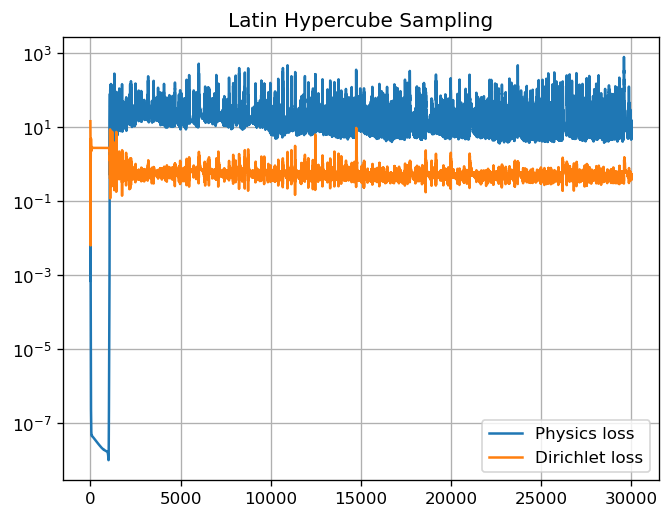

In [37]:

plt.figure(dpi= 120)
plt.title('Latin Hypercube Sampling')
plt.semilogy(bottle_pinn.physics_losses, label = "Physics loss")
plt.semilogy(bottle_pinn.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_20613/1763721147.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto')


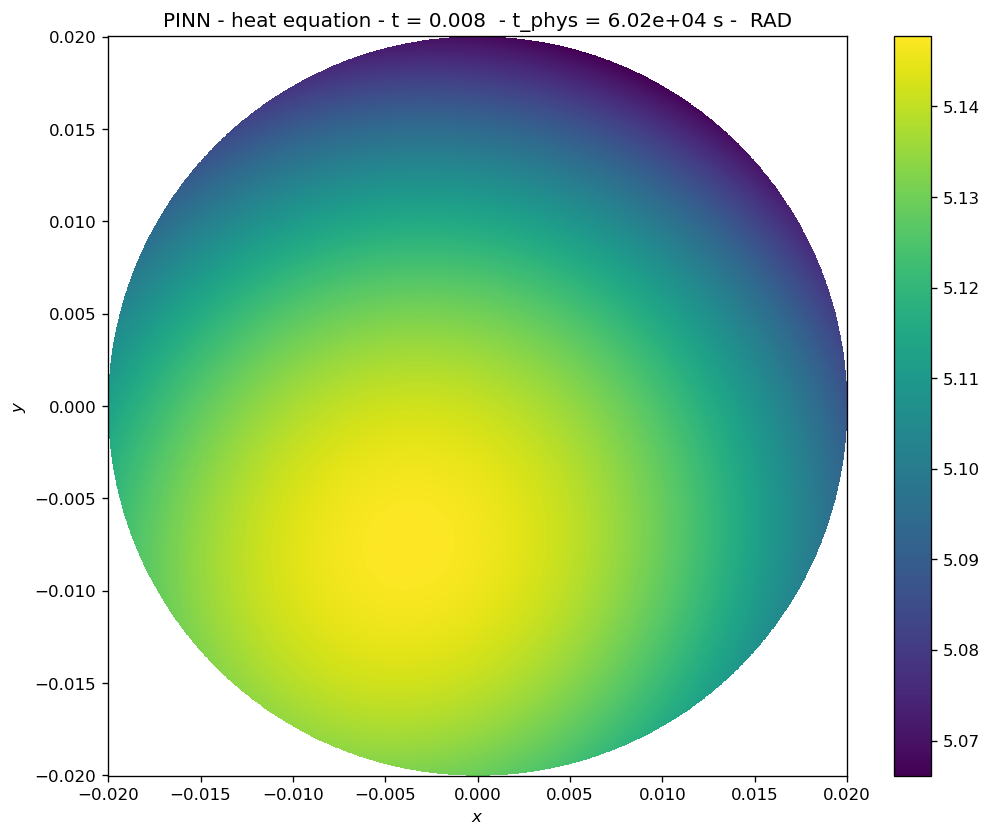

In [46]:
radius = 0.02
t_check = 0.008

N_r, N_theta = 1000, 2000
r = np.linspace(0, radius, N_r)
theta = np.linspace(0, 2*np.pi, N_theta)
R, Theta = np.meshgrid(r, theta)  # both shape (N_theta, N_r)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)

with torch.no_grad():
    u_pred = bottle_pinn.model(grid_points_torch)  # shape (N_theta*N_r, 1)

res = u_pred.numpy().reshape(X.shape)  # back to (N_theta, N_r) to match X, Y grid

fig, ax = plt.subplots(figsize=(10, 8), dpi = 120)
#pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto', vmin=4, vmax=20)
pcm = ax.pcolormesh(X, Y, res, cmap='viridis', shading='auto')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax)
ax.set_title(f'PINN - heat equation - t = {t_check}  - t_phys = {t_check/alpha_water:.3g} s -  RAD')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.savefig('results/heat_pinn.png')
plt.show()

# STUFF TO DO/PROBLEMS TO FIX

convergence slow

also, difficult to see a nice gradient on the boundary. tried raising the boundary weight to 100 (from 10), did not really work. 

plus the cooling down seems a bit slow, compared to experience. should need to check with my next beer :)
